`Université Paris-Saclay                                                                                       2024-2025`

`OLMA 253 :  Analyse Numérique avec Python                                                                LDD2 EM-IM`

`@c Jean-Baptiste APOUNG KAMGA`                                    jean-baptiste.apoung-kamga@universite-paris-saclay.fr

----

FEUILLE DE TP 3

---
# Polynôme interpolateur de Lagrange (Partie 1)
---

***

**Nous proposons ici un élement de solution de la fiche. Les réponses aux questions seront données dans le format suivant** : 

<p style="color:#0008ff;font-family:courier; font-size:100%; font-weight:bold;background-color:powderblue;">
    Réponse.
</p>
<br>

<div style="color:#0008ff;">
    
Encore une fois, ceci n'est qu'un élément de réponse comme il peut en exister plusieurs. 
<ul>
<li> Il n'est fourni que pour ceux qui auraient accusé du retard dans les Tps.
<li> Il opte donc pour des constructions simplifiées de Python au détriment des techniques avancées.
</ul>   
    Je vous conseille donc de toujours <strong>privilégier vos propres codes</strong> produits pendant les séances de Tps. 
    
Car il vous sera plus facile de les reproduire, dans un autre contexte.
</div>

En fin de la fiche vous trouverez  : 

<div style="color:#ff0008;font-family:courier; font-size:100%; font-weight:bold;background-color:powderblue;">
 
<ul><li>
 une petite question d'exploration 
</li></ul>
</div>
    
<div style="color:#ff08ff;font-family:courier; font-size:100%; font-weight:bold;background-color:powderblue;">

<ul><li> un petit tutoriel sur une technique de mise en oeuvre, qui peut être utile pour certains.
</li></ul>
</div>
 
 
 ***

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np                       # pour les numpy array
from scipy.interpolate import lagrange   # interpolation de Lagrange
import matplotlib.pyplot as plt          # librairie graphique

---

# I- Préliminaires : 
## Suites - Convergence- Ordre (Vitesse) - Constante asymptotique

---

Dans la suite du cours nous produirons des méthodes numériques d'approximation. C'est-à-dire permettant 
de construire des solutions approchées aux problèmes sous la main. Ceci genèrera des suites numériques. 

Et la qualité de l'approximation sera mésurée par la manière donc la suite des solutions approchées converge vers la solution exacte.

Nous réservons donc cette partie de la fiche à l'analyse de convergences des suites.

**Rappels (voir cours):**

Soit $(x_n)_{n\in\mathbb{N}}$ une suite d'éléments de $\mathbb{R}^n$ et $x^*$ un élement de $\mathbb{R}^n$.  
On désigne par $\| . \|$ une norme sur $\mathbb{R}^n$ (on rappelle que $\mathbb{R}^n$ étant de dimension fine, 
touttes les normes y sont équivalentes).
>- **Définitions:**
>>- La suite est dite **convergente d'ordre** $q\in \mathbb{N}$ si et seulement si : $\exists K_q \in\mathbb{R}^*_+$ tel que  $\displaystyle \lim_{n -> \infty} \frac{\|x_{n+1} - x^*\|}{\|x_n - x^*\|^q} = K_q$. 
>>- La constante $K_r$ est appelée **constante asymptotique** de la suite. Elle est dificile à obtenir en pratique (puisqu'il faut pour cela disposer de la limite $x^*$). Ainsi dans la pratique on arrive plutôt à obtenir un majorant de $K_r$.
>>- La quantité $e_n = x^* - x_n$ est appelée **l'erreur à l'itération $n$**.
>- **Caractérisation:** 
ainsi une suite sera dite **convergente d'ordre $q$ ssi**:
$$
\exists N\in\mathbb{N}, \exists A, B \in\mathbb{R} : \forall n > N, 0 < A < \frac{\|e_{n+1}\|}{\|e_n\|^q} < B < \infty.
$$

Le but de l'analyse de la suite est de :
>- dire si la suite converge
>- et si elle converge,
>>- déterminer l'ordre de convergence **q**
>>- déterminer (**si possible**) la constante  **Kq** (qui joue un rôle important lorsque la convergence est d'ordre 1).


## Exercice 1 :  Ordre de convergence des suites


### Question 1.1:

> Fournir une fonction `TraquerOrdre(xn, limit)`
qui calcul l'ordre de convergence de la suite `xn`


In [30]:
## METTRE LE CODE ICI
def TraquerOrdre(xn, lim = 0.0, ax = None, title=''):
    '''
    Fonction qui calcule l'ordre de convergence de la suite
    passée en argument
    ENTREE:
      xn    -> tableau des éléments de la suite
      lim   -> limite de la suite
      ax    -> est la fenêtre graphique sur laquelle le dessin s'effectue
      title -> le titre à associer
    SORTIE:
       - ordre de la suite
       - graphique qui trace à l'echelle log 
           - la courbe log(|x_n - lim|) -> log(|x_{n+1} - lim|)
           - la courbe de regression linéaire associée
    '''
    #COMPLETER
    # Trancer la courbe log(|x_n - lim|) -> log(|x_{n+1} - lim|) en pointillés   
    e = np.log(np.abs(xn - lim))
    ex, ey = e[0:-1], e[1:]
    ax.plot(ex, ey, '+', label='nuages')    
    # Estimer l' ordre q de convergence de la suite (utiliser une des approches vues en cours)
    a, b = np.polyfit(ex, ey,1)
    # Représenter sur le même graphique la courbe de pente q (ici q est réel et non entier) en ligne continue
    ax.plot(ex, b + a * ex, label=f"$x \mapsto {b:3.2f} + {a:3.2f}\, x$")
    # Mettre les légendes 
    ax.legend()
    # Mettre le titre il doit contenir l'information sur l'ordre de convergence estimé 
    ax.set_title(title + f" convergence d'ordre :{a:3.2f}")
    # Décoration des axes
    ax.set_xlabel(f"$\log(|e_n|)$")
    ax.set_ylabel(f"$\log(|e_{{n+1}}|)$")
    

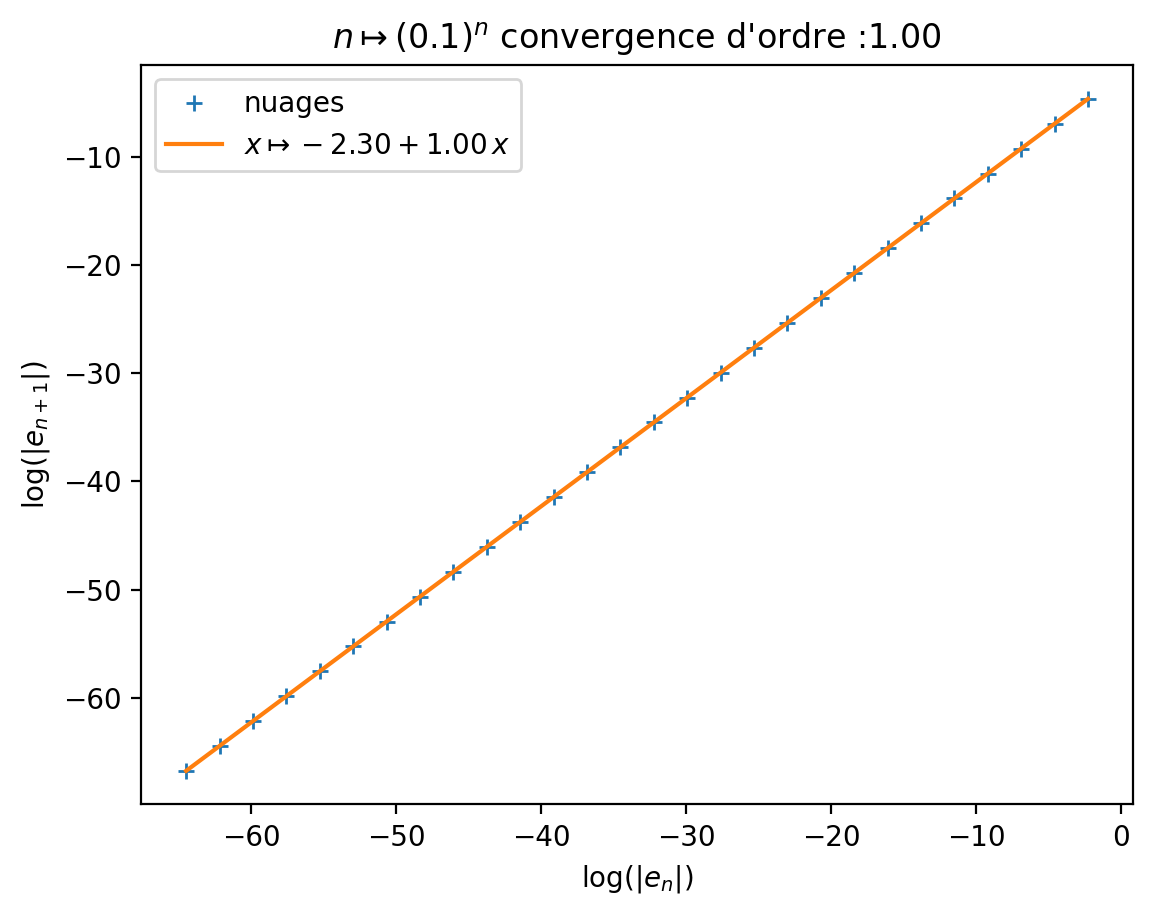

In [31]:
# Tester rapidement votre algorithme
n = np.arange(1,30)
a = (0.1)**n
fig, ax = plt.subplots(1,1)
TraquerOrdre(a, 0.0, ax, title="$ n \mapsto (0.1)^n $")


### Question 1.2
 On considère les suites suivantes ;
  $$ u_n = (0.08)^n, \qquad v_n = (0.99)^n  \qquad  w_n  = (0.8)^{2^n}$$
> Calculer et affichera les 30 premiers termes de ces suites. 
> Déduire graphiquement qu'elles convergent. *On pourra représenter la ligne horizontale de hauteur `0` (l'axe des abcisses)* 


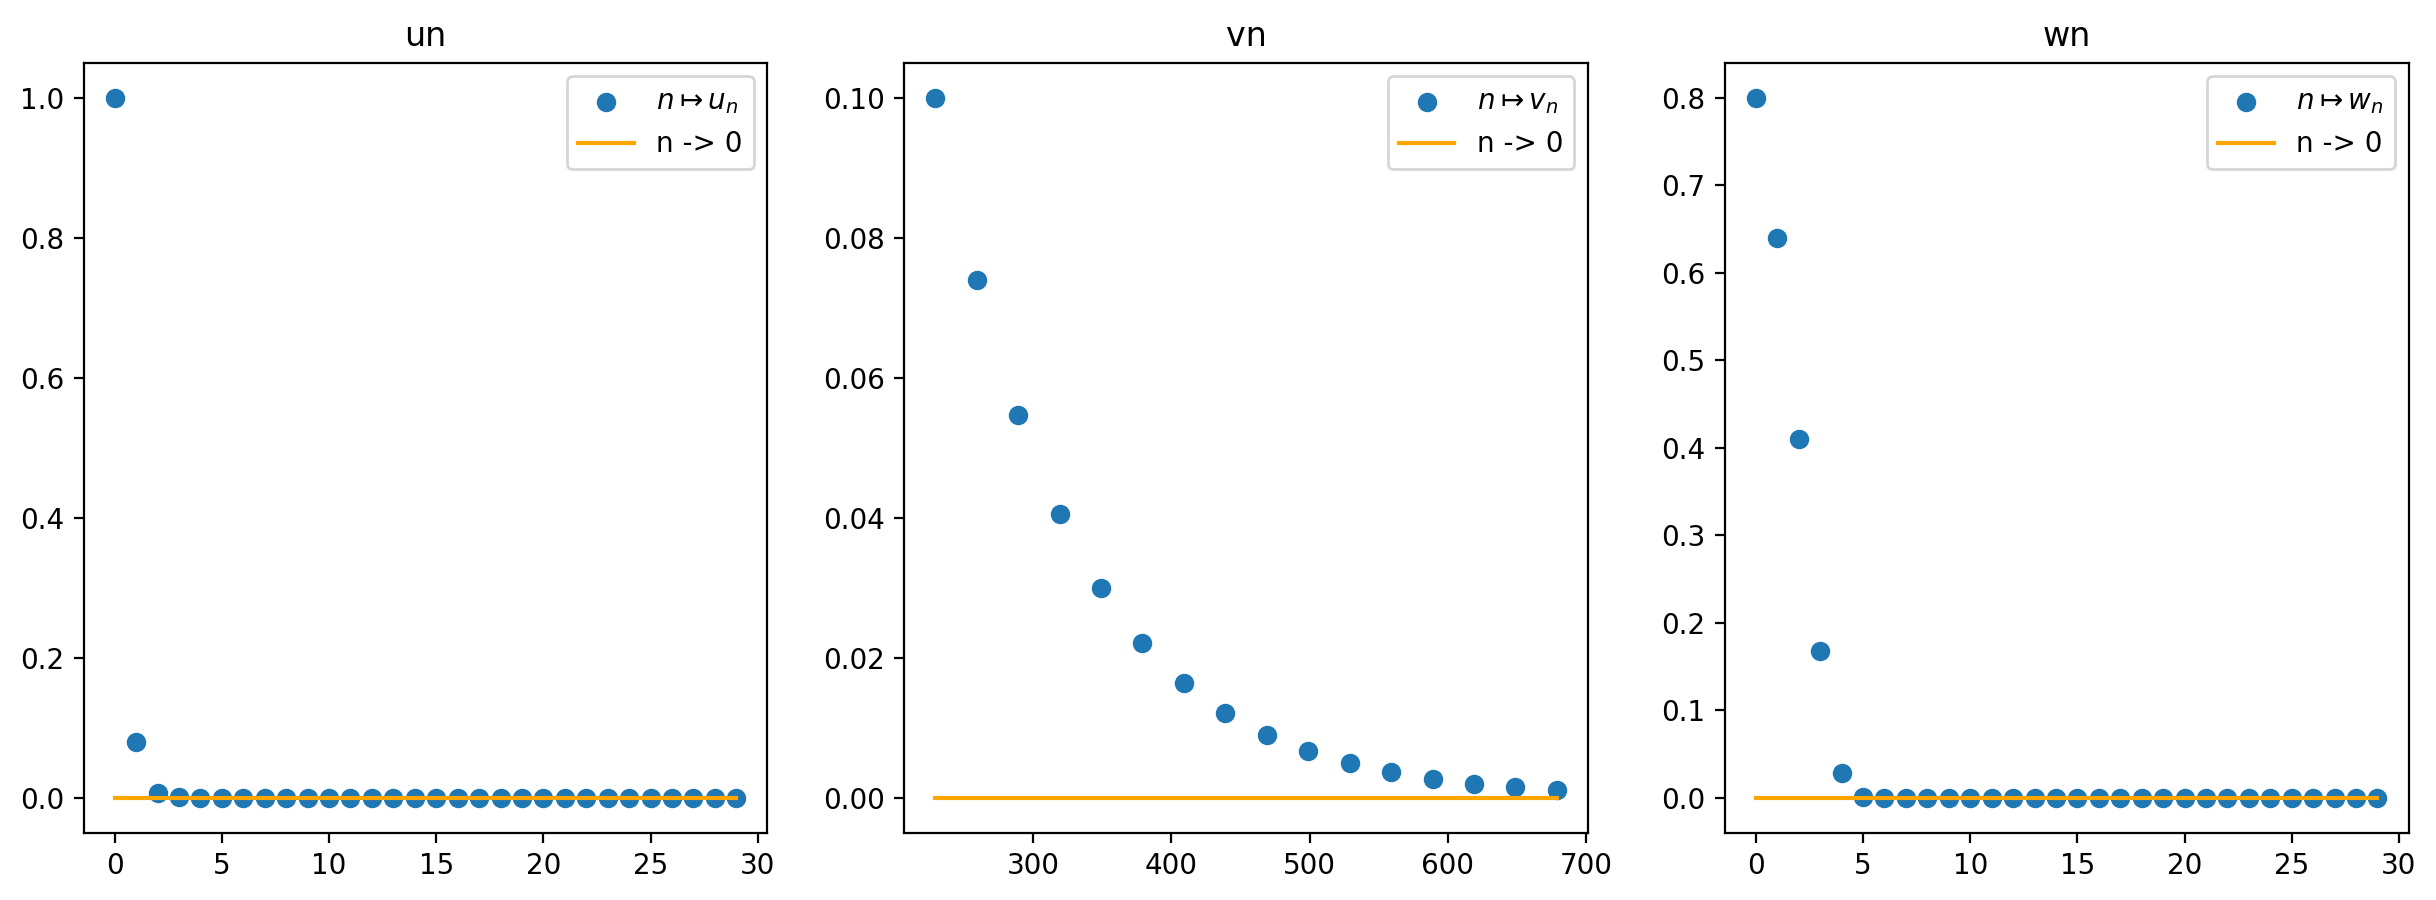

In [4]:
# METTRE VOTRE CODE ICI 

n = np.arange(30)
nv = np.arange(229,3*229,30)
u = 0.08**n
v = 0.99**nv
w = 0.8**(2**n)

fig, ax = plt.subplots(1,3, figsize=(15,5))

# ON PEUT METTRE DANS UNE BOUCLE POUR SIMPLIFIER LES LIGNES DE CODE 

ax[0].scatter(n,u, label='$n \mapsto  u_n$')
ax[0].plot(n,0*u, color='orange', label='n -> 0')
ax[0].legend()
ax[0].set_title("un")

ax[1].scatter(nv,v,label='$n \mapsto  v_n$')
ax[1].set_title("vn")
ax[1].plot(nv,0*v, color='orange', label='n -> 0')
ax[1].legend()

ax[2].scatter(n,w, label='$n \mapsto  w_n$')
ax[2].set_title("wn")
ax[2].plot(n,0*w, color='orange', label='n -> 0')
ax[2].legend()
plt.show()



### Question 1.3

 Déterminer si elles convergent, **l'ordre** de convergence des suites ci-dessus

>- Vous pourrez vous servir de votre fonction `TraquerOrdre`  si elle est fonctionnelle
>- Vous pourrez aussi représenter sur un même graphique la courbe $\log(e_n) \mapsto \log(e_{n+1})$, ainsi que des droites de pente 1, 2, 3 passant par un point bien choisi.
 

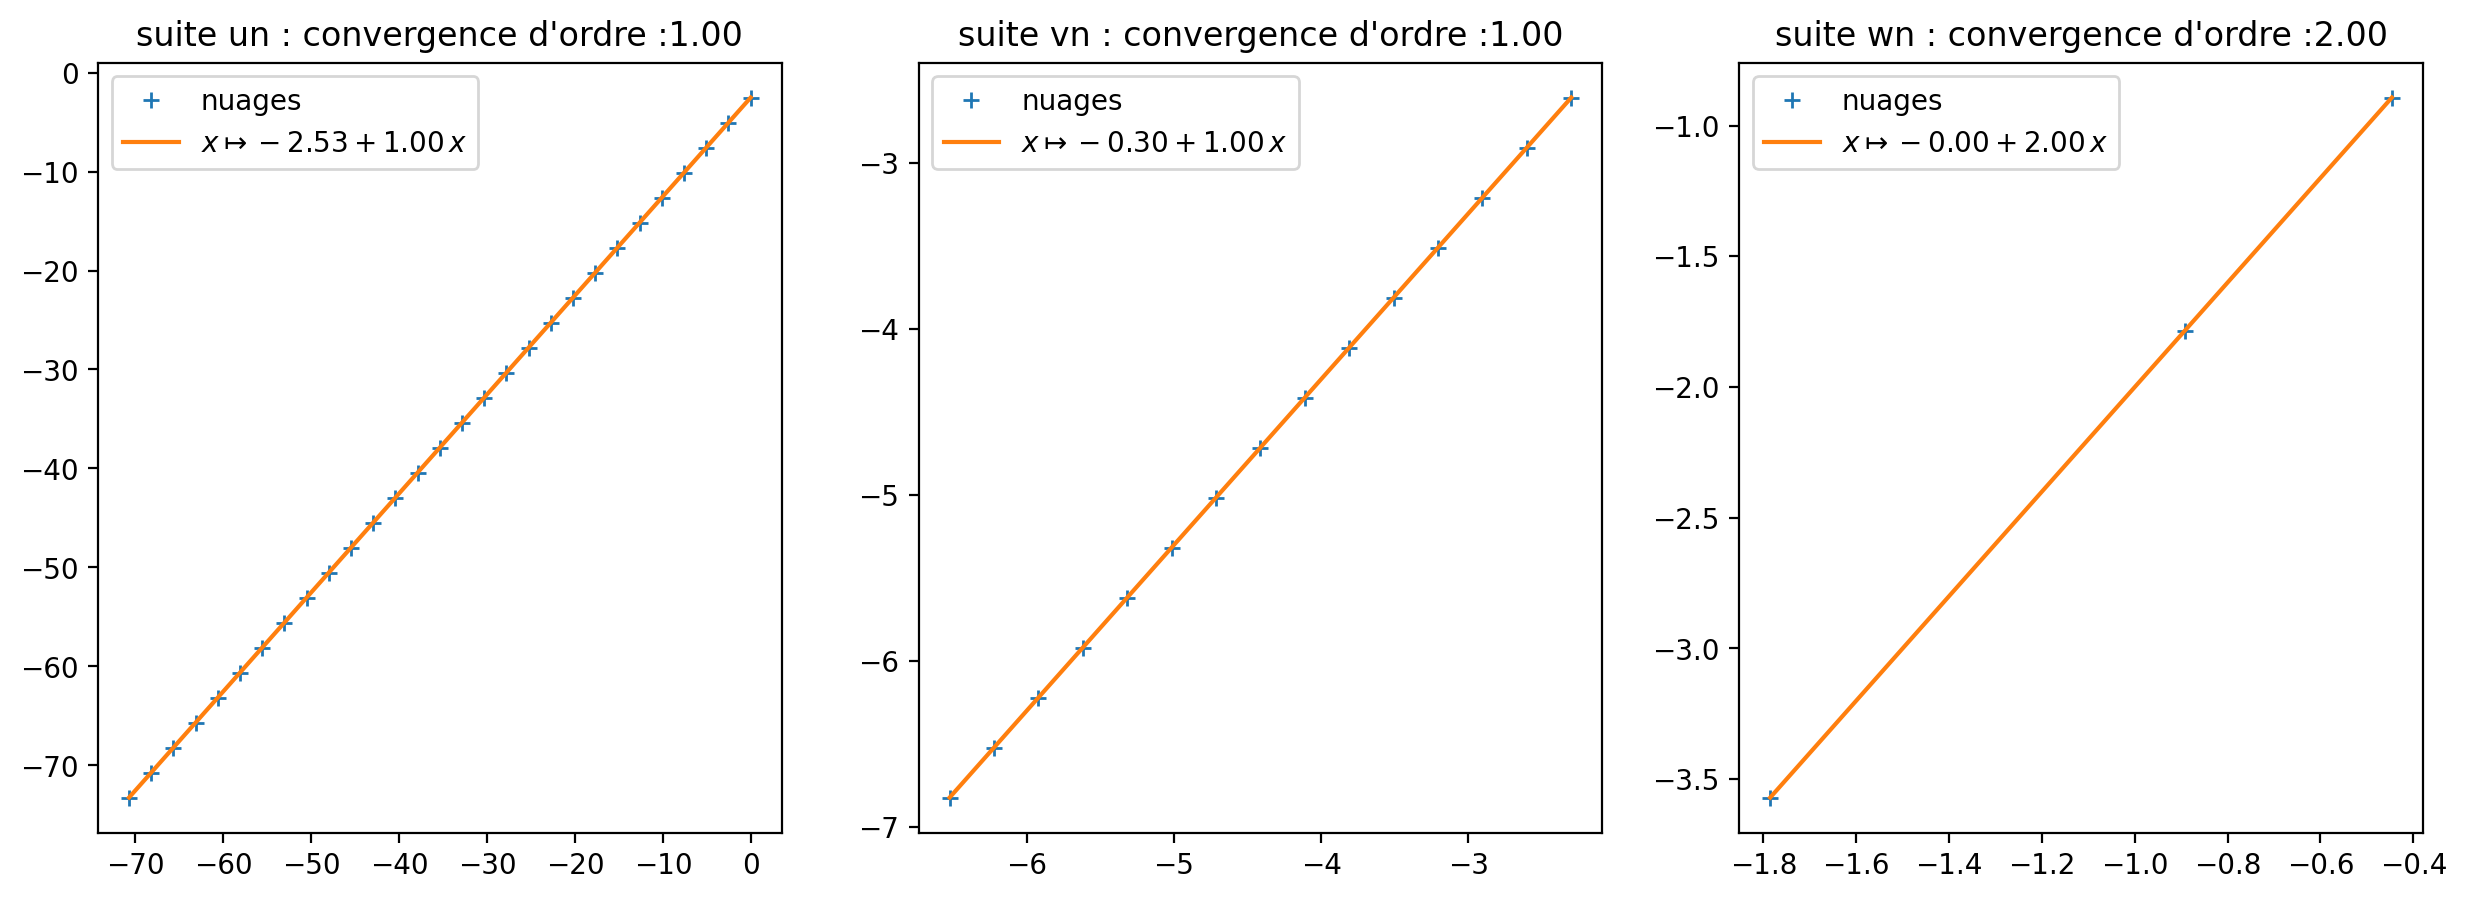

In [5]:
# METTRE VOTRE CODE ICI


n = np.arange(30)
u = 0.08**n
#v = 0.99**n
v = 0.99 ** np.arange(229,3*229,30)
w = 0.8**(2**n[1:5])    # pour la suite w, on utilise moins de termes car on converge  trop vite 

fig, ax = plt.subplots(1,3, figsize=(15,5))

TraquerOrdre(u, 0.0, ax[0], title='suite un :')

TraquerOrdre(v, 0.0, ax[1], title='suite vn :')

TraquerOrdre(w, 0.0, ax[2], title='suite wn :')


<div style="color:#0008ff;font-family:courier; font-size:100%; font-weight:bold;background-color:powderblue;">

Remarque : 
    <ul>
<li> on a été contraint de limiter le nombre de termes de la suite w, qui convergeant trop vite peut rendre difficile le calcul du <strong>log</strong> nécessaire dans <span style="background-color: #FFFFFF; color:#000000">TraquerOrdre</span>
<li> On peut donc mener un travail dans la fonction  <span style="background-color: #FFFFFF; color:#000000">TraquerOrdre</span> pour se prémunir de cela. Nous le ferons cela dans le <span style="background-color: #FFFFFF; color:#000000">Bloc5</span> de ce cours.

</ul>
</div>

---
## Exercice 2 :  Termes ajoutés par itération 

### Question 2.1

 Pour chacune des suites $(u_n)$ et $(v_n)$ ci-dessus

* calculer à la main sa constante **asymptotique**  `K`
* et afficher la valeur de $ \frac{-1}{\log_{10}(K)}$


In [6]:
## METTRE LE CODE ICI

Ku = 0.08
Kv = 0.99

# COMPLETEZ

fmt = "Pour {:s}, constante asymptotique K = {:}, nb iétrations pour gain d'une décimale: -1/log(K) = {:4.3f} "
print(fmt.format("un", Ku, -1/(np.log(Ku)/np.log(10.))))
print(fmt.format("vn", Kv, -1/(np.log(Kv)/np.log(10.))))
 

Pour un, constante asymptotique K = 0.08, nb iétrations pour gain d'une décimale: -1/log(K) = 0.912 
Pour vn, constante asymptotique K = 0.99, nb iétrations pour gain d'une décimale: -1/log(K) = 229.105 


### Question 2.2
 
 Montrer et vérifier numériquement qu'à chaque itération  
 * avec la suite $v_n$ il faut **230** itérations pour gagner une décimale
 * avec la suite $u_n$ on gagne **une** décimale à chaque itération
 
*Formatter une sortie du type* 
```
 ---------------------------------
|  n  |           un            |
---------------------------------
|  0  |  1.000000000000000e+00  |
|  1  |  8.000000000000000e-02  |
|  2  |  6.400000000000000e-03  |
|  3  |  5.120000000000001e-04  |
|  4  |  4.096000000000000e-05  |
|  5  |  3.276800000000001e-06  |
|  6  |  2.621440000000000e-07  |
|  7  |  2.097152000000000e-08  |
|  8  |  1.677721600000000e-09  |
|  9  |  1.342177280000000e-10  |
---------------------------------
On voit bien qu'on gane un chiffre décimale à chaque itération 
```

In [7]:
# METTRE VOTRE CODE ICI  pour un

fmt ='-'*33
fmt2 ="|{:^5s}|{:^25s}|" 
fmt3 ="|{:^5d}|{:^25.15e}|" 

N = 10
print(fmt)
print(fmt2.format("n", "un"))
print(fmt)

for n in range(N):
    print(fmt3.format(n, 0.08**n))
            
print(fmt)
print("On voit bien qu'on gagne un chiffre décimal à chaque itération ")

---------------------------------
|  n  |           un            |
---------------------------------
|  0  |  1.000000000000000e+00  |
|  1  |  8.000000000000000e-02  |
|  2  |  6.400000000000000e-03  |
|  3  |  5.120000000000001e-04  |
|  4  |  4.096000000000000e-05  |
|  5  |  3.276800000000000e-06  |
|  6  |  2.621440000000000e-07  |
|  7  |  2.097152000000000e-08  |
|  8  |  1.677721600000000e-09  |
|  9  |  1.342177280000000e-10  |
---------------------------------
On voit bien qu'on gagne un chiffre décimal à chaque itération 


In [8]:
#METTRE VOTRE CODE ICI  pour vn

fmt ='-'*33
fmt2 ="|{:^5s}|{:^25s}|" 
fmt3 ="|{:^5d}|{:^25.15e}|" 
fmt4 ="|{:^5d}|{:^25.15e}| <----- Gain d'une décimale" 

N = 230 *4

print(fmt)
print(fmt2.format("n", "vn"))
print(fmt)
snap = 0
for n in range(0,N):
    if(n == snap):
        print(fmt)
        if n > 0 : print(fmt3.format(n-1, (0.99)**(n-1)))    
        print(fmt3.format(n, (0.99)**(n)))
        print(fmt4.format(n+1, (0.99)**(n+1)))
        print(fmt3.format(n+2, (0.99)**(n+2)))
        snap += 229
print(fmt)
print("On voit bien qu'on ne gagne un chiffre décimal qu'après 230 itérations ")


---------------------------------
|  n  |           vn            |
---------------------------------
---------------------------------
|  0  |  1.000000000000000e+00  |
|  1  |  9.900000000000000e-01  | <----- Gain d'une décimale
|  2  |  9.801000000000000e-01  |
---------------------------------
| 228 |  1.011170447085751e-01  |
| 229 |  1.001058742614894e-01  |
| 230 |  9.910481551887448e-02  | <----- Gain d'une décimale
| 231 |  9.811376736368574e-02  |
---------------------------------
| 457 |  1.012241016329002e-02  |
| 458 |  1.002118606165712e-02  |
| 459 |  9.920974201040548e-03  | <----- Gain d'une décimale
| 460 |  9.821764459030144e-03  |
---------------------------------
| 686 |  1.013312719029533e-03  |
| 687 |  1.003179591839237e-03  |
| 688 |  9.931477959208451e-04  | <----- Gain d'une décimale
| 689 |  9.832163179616365e-04  |
---------------------------------
| 915 |  1.014385556387383e-04  |
| 916 |  1.004241700823509e-04  |
| 917 |  9.941992838152741e-05  | <----- G

### Question 2.3 : Interprétations 

>- Commentez les résultats des questions précédentes en remaquant que :
>>- les deux suites sont bien convergentes d'ordre 1,
>>- mais que l'une des suites converge plus vite que l'autre.

>- Si ces suites représentaient chacune la suite des erreurs de deux méthodes différentes d'approximation d'un même problème continu. Laquelle des méthodes serait la plus conseillée ?




<div style="color:#0008ff;font-family:courier; font-size:100%; font-weight:bold;background-color:powderblue;">

<ul>
<li> On a bien deux suites qui convergent à l'ordre 1.  A ce stade aucune n'est avantageuse.
<li> Mais lorsque qu'on regarde de près (ici la constante asymptotique), on se rend compte que malgré le même ordre 1 de convergence, l'une est beaucoup plus lente que l'autre: Il faut 230 itérations pour $v_n$ pour gagner une décimale alors qu'il n'en faut que 1 pour $u_n$.
<li> Si donc $u_n$ et $v_n$  representaient les erreurs de deux méthodes d'approximation d'un même problème, 
malgré le fait que ces méthodes soient d'ordre 1 (comme le montrent ces suites),  la méthode dont $u_n$ décrit l'erreur, fournirait la bonne solution avec <span style="background-color: #FFFFFF; color:#000000">10 décimales exactes</span> au bout de seulement <span style="background-color: #FFFFFF; color:#000000">10 itérations</span>, alors que la méthode 
décrite par $v_n$ ne fournirait un résultat équivatent qu'au bout de <span style="background-color: #FFFFFF; color:#000000">2300 = 230 x 10</span> itérations.
L'une des méthodes serait donc <span style="background-color: #FFFFFF; color:#000000">très largement</span> supérieure à l'autre.
    </ul>
</div>

---

# II-  Polynôme interpolateur de Lagrange
---

Nous rappelons le résultat d'existence et d'unicité vu en cours

> **(Polynôme interpolateur de Lagrange)**<br>
> Etant donnés $N$ un entier strictement positif, $x_1,\ldots,x_N$ des réels deux à deux distincts et $y_1,\ldots,y_N$ des réels, il existe un unique polynôme $P$ qui vérifie
> $$ P\in\mathbb{R}_{N-1}[X], \qquad P(x_i)=y_i, \quad 1\leq i\leq N.$$

---
## Exercice 3 :  Construction en utilisant les modules `numpy` et `scipy`

Le module `numpy` permet la manipulation de polynômes réels à l'aide de la classe `poly1d`. Voici un exemple pour le polynôme $P=X^2-2$

```python
P = np.poly1d([1, 0, -2])
print(P)
```

Il est possible de faire des manipulations algébriques sur les polynômes :

```python
X = np.poly1d([1, 0])
P = X**2 - 2
print(P)
```

Il est également possible d'évaluer un polynôme comme une fonction (évaluation sur un scalaire ou sur un tableau `numpy`) :

```python
print(P(1))
print(P(np.linspace(0, 1, 11)))
```

In [9]:
# COPIER ET TESTER LES CODES CI-DESSUS

P = np.poly1d([1, 0, -2])
print(P)


   2
1 x - 2


In [10]:
# COPIER ET TESTER LES CODES CI-DESSUS

X = np.poly1d([1, 0])
P = X**2 - 2
print(P)


   2
1 x - 2


In [11]:
# COPIER ET TESTER LES CODES CI-DESSUS

print(P(1))
print(P(np.linspace(0, 1, 11)))

-1
[-2.   -1.99 -1.96 -1.91 -1.84 -1.75 -1.64 -1.51 -1.36 -1.19 -1.  ]


Le module `scipy.interpolate` permet de déterminer le polynôme interpolateur à l'aide de la fonction `lagrange`. Voici un exemple d'utilisation pour déterminer le polynôme interpolateur de Lagrange aux points $(0, -2)$, $(1,-1)$ et $(2, 2)$ (c'est encore et toujours le polynôme $X^2-2$...)

```python
from scipy.interpolate import lagrange
x = np.array([0, 1, 2])
y = np.array([-2, -1, 2])
P = lagrange(x, y)
print(P)
```

In [12]:
# COPIER ET TESTER LES CODES CI-DESSUS

x = np.array([0, 1, 2])
y = np.array([-2, -1, 2])
P = lagrange(x, y)
print(P)


   2
1 x - 2


### Question 3.1

> Proposez une fonction `interp` qui 
> * prend en argument deux `ndarray` `x` et `y` de taille `N` et un `ndarray` `xx` de taille `M` ;
> * calcule le polynôme interpolateur de Lagrange aux points donnés par les vecteurs `x` et `y` en utilisant les fonctions des modules `numpy` et `scipy` ;
> * retourne l'évaluation de ce polynôme aux points du vecteur `xx`.

*Veillez à commenter votre fonction.*

In [13]:
def interp(x, y, xx):
    """
    calcule et évalue le polynôme interpolateur de Lagrange
    en utilisant :
        . la fonction lagrange du module scipy.interpolate
        . la classe poly1d du module numpy
    
    Parameters
    ----------
    
    x: ndarray
        abscisses des points d'interpolation
        
    y: ndarray
        ordonnées des points d'interpolation
        
    xx: ndarray
        abscisses des points d'évaluation
        
    Returns
    -------
    
    ndarray
        ordonnées des points d'évaluation
    """
    P = lagrange(x, y)
    return P(xx)

### Question 3.2

> Afin de tester votre fonction : en prenant $N=5$,
> 1. prenez $N$ points équirépartis entre 0 et 1 (ce sera notre vecteur `x`) ;
> 2. générez $N$ valeurs aléatoires entre 0 et 1 (ce sera notre vecteur `y`) ;
> 3. tracez dans une fenêtre graphique le nuage de points d'abscisses `x` et d'ordonnées `y` à l'aide d'une commande `scatter` ;
> 4. ajoutez le tracé du polynôme interpolateur en prenant `xx` un vecteur de taille grande (plutôt 100 ou 200 points équi-répartis entre 0 et 1) ;
> 5. vérifiez que le polynôme interpolateur passe bien par les points d'interpolation.

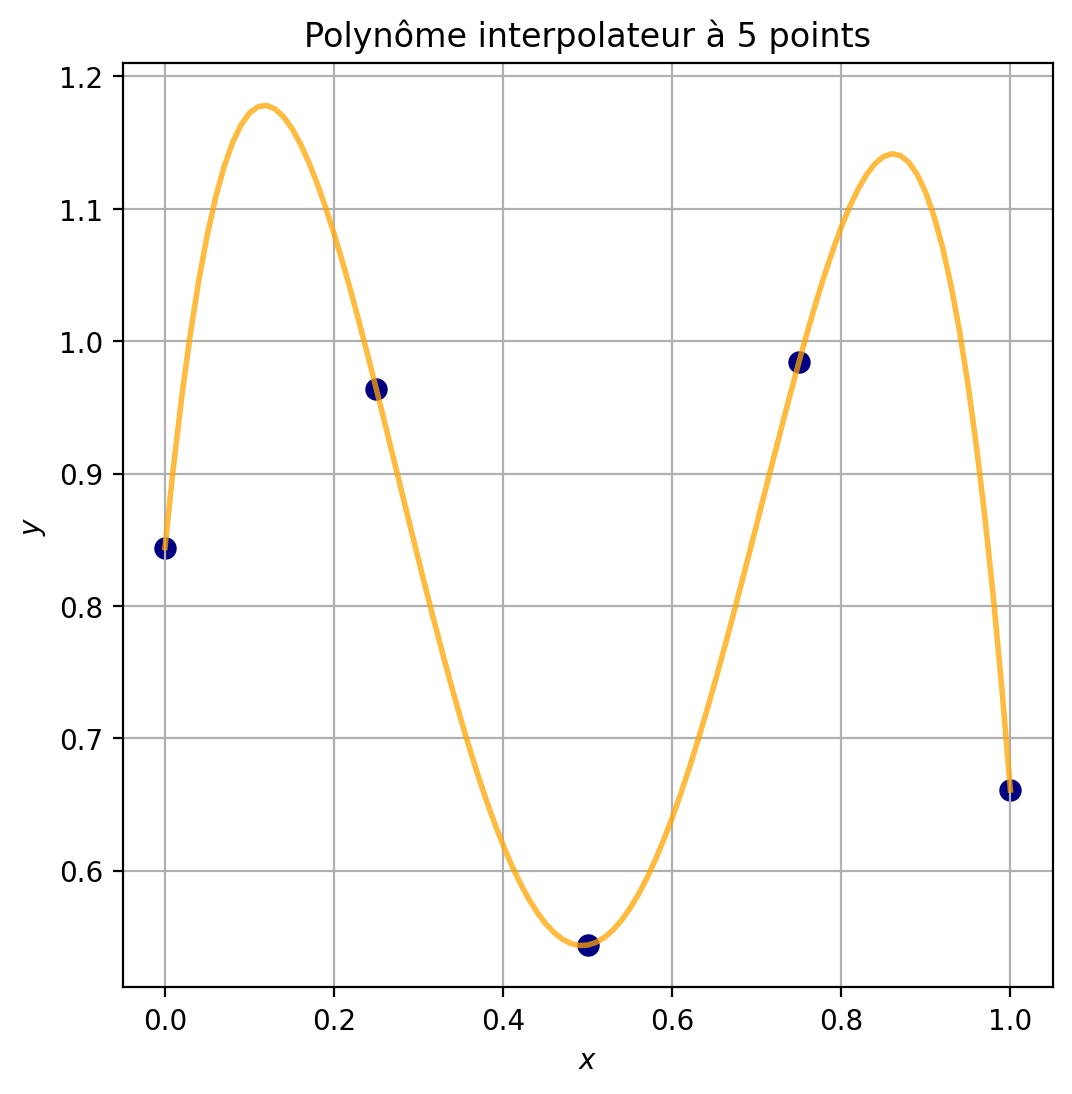

In [33]:
#METTRE LE CODE ICI

N = 5

# COMPLETEZ 

x = np.linspace(0, 1, N)      #  x_i dans le cours
y = np.random.rand(N)         #  y_i dans le cours 
xx = np.linspace(0, 1, 101)   #  points pour représenter graphiquement (le polynome)
yy = interp(x, y, xx)         #  evaluation du polynome aux points du graphique

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1)
ax.scatter(x, y, s=50, color='navy', alpha=1)
ax.grid(True)
ax.plot(xx, yy, linewidth=2, alpha=0.75, color='orange')
ax.set_title(f"Polynôme interpolateur à {N:} points")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
plt.show()

<div style="color:#0008ff;font-family:courier; font-size:100%; font-weight:bold;background-color:powderblue;">

En séance de Tp, certains d'entre -vous ont encore des difficultés avec les graphiques. 
    
Je vous conseille donc d'utiliser les approches simples. Vous aurez le temps dans votre cursus de vous orienter vers des approches plus évoluées.

Par exemple, on aurait pu répondre à la question ci-dessus de la manière suivante :
</div>

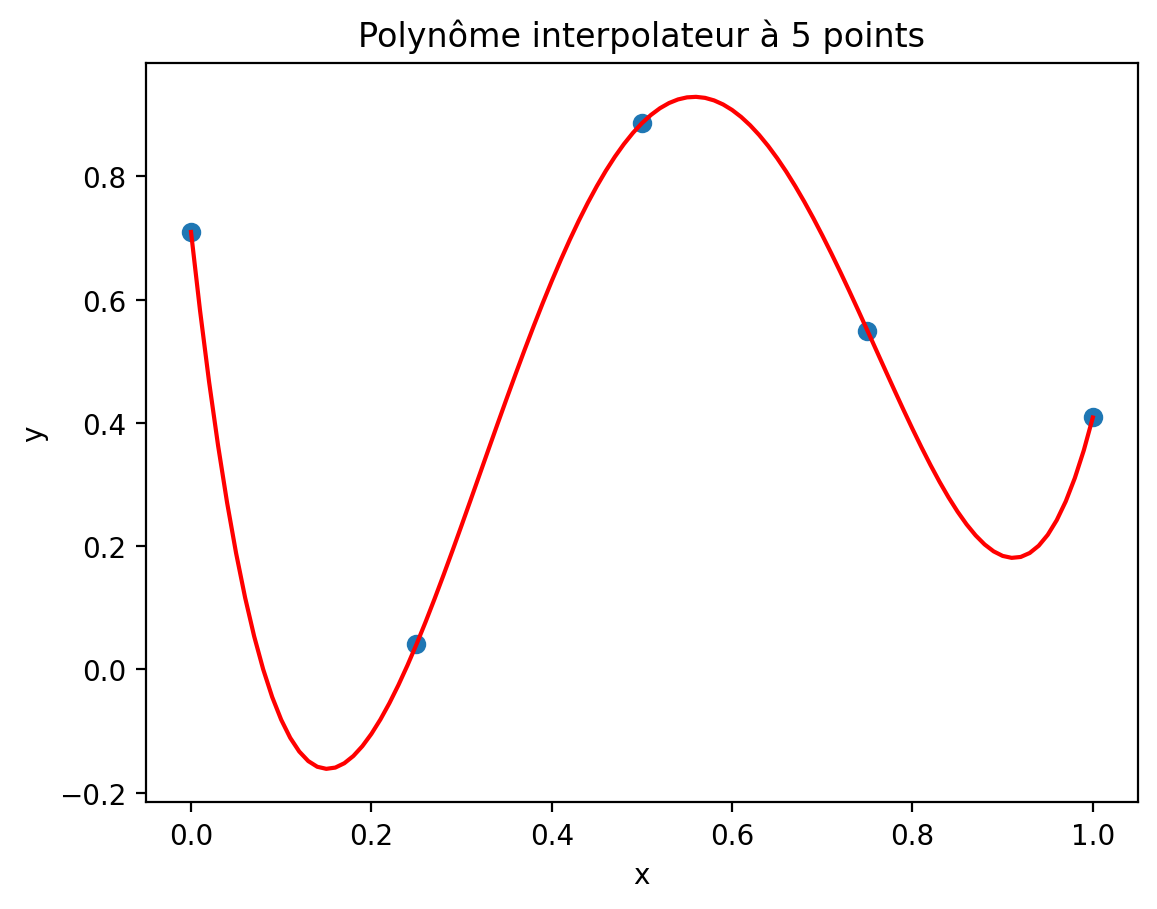

In [32]:
N = 5

xi = np.linspace(0, 1, N)    # le x pour abscisse et le i vous rappelera que ce sont les points d'interpolation
yi = np.random.rand(N)       # le y pour ordonnées et le i vous rappelera que ce sont les points d'interpolation

xg = np.linspace(0, 1, 101)  # abscisses des points pour le graphique. Nous avons toujours doubler les x (ie xx) pour cela
yg = interp(xi, yi, xg)      # interpolation de lagrange évaluée aux points fournis pour le graphique 

plt.scatter(xi, yi)          # on place les point d'interpolation      
plt.plot(xg, yg, '-r')       # on trace l'interpolé  ici  en rouge 'r' et trait continu '-'
plt.title(f"Polynôme interpolateur à {N} points")
plt.xlabel("x")
plt.ylabel("y")
#plt.grid() # on peut aussi mettre la grille. Mais ce n'est pas nécessaire 
plt.show()

---
## Exercice 4 : Test de l'interpolation sur quelques fonctions

Nous allons à présent tester l'interpolation en prenant comme points d'interpolation des points qui sont sur le graphe de ces 4 fonctions. 

\begin{align}
f_0(x) &= \exp(-3(x-1.2)^2), &
f_1(x) &= \frac{x^2-2}{1+2x},\\
f_2(x) &= \frac{1}{1+(x-1.5)^2},&
f_3(x) &= \frac{\sin(2\pi x)}{1.1 - \sin(\pi x)}.
\end{align}



### Question 4.1

> Définissez ces 4 fonctions et tracez les sur l'intervalle $[0, 3]$.

In [16]:
# Définition des fonctions

f = [
    lambda x: np.exp(-3*(x - 1.2)**2),
    lambda x: (x**2 - 2) / (1 + 2*x),
    lambda x: 1 / (1 + (x - 1.5)**2),
    lambda x: np.sin(2 * np.pi * x) / (1.1 - np.sin(np.pi * x)),
]

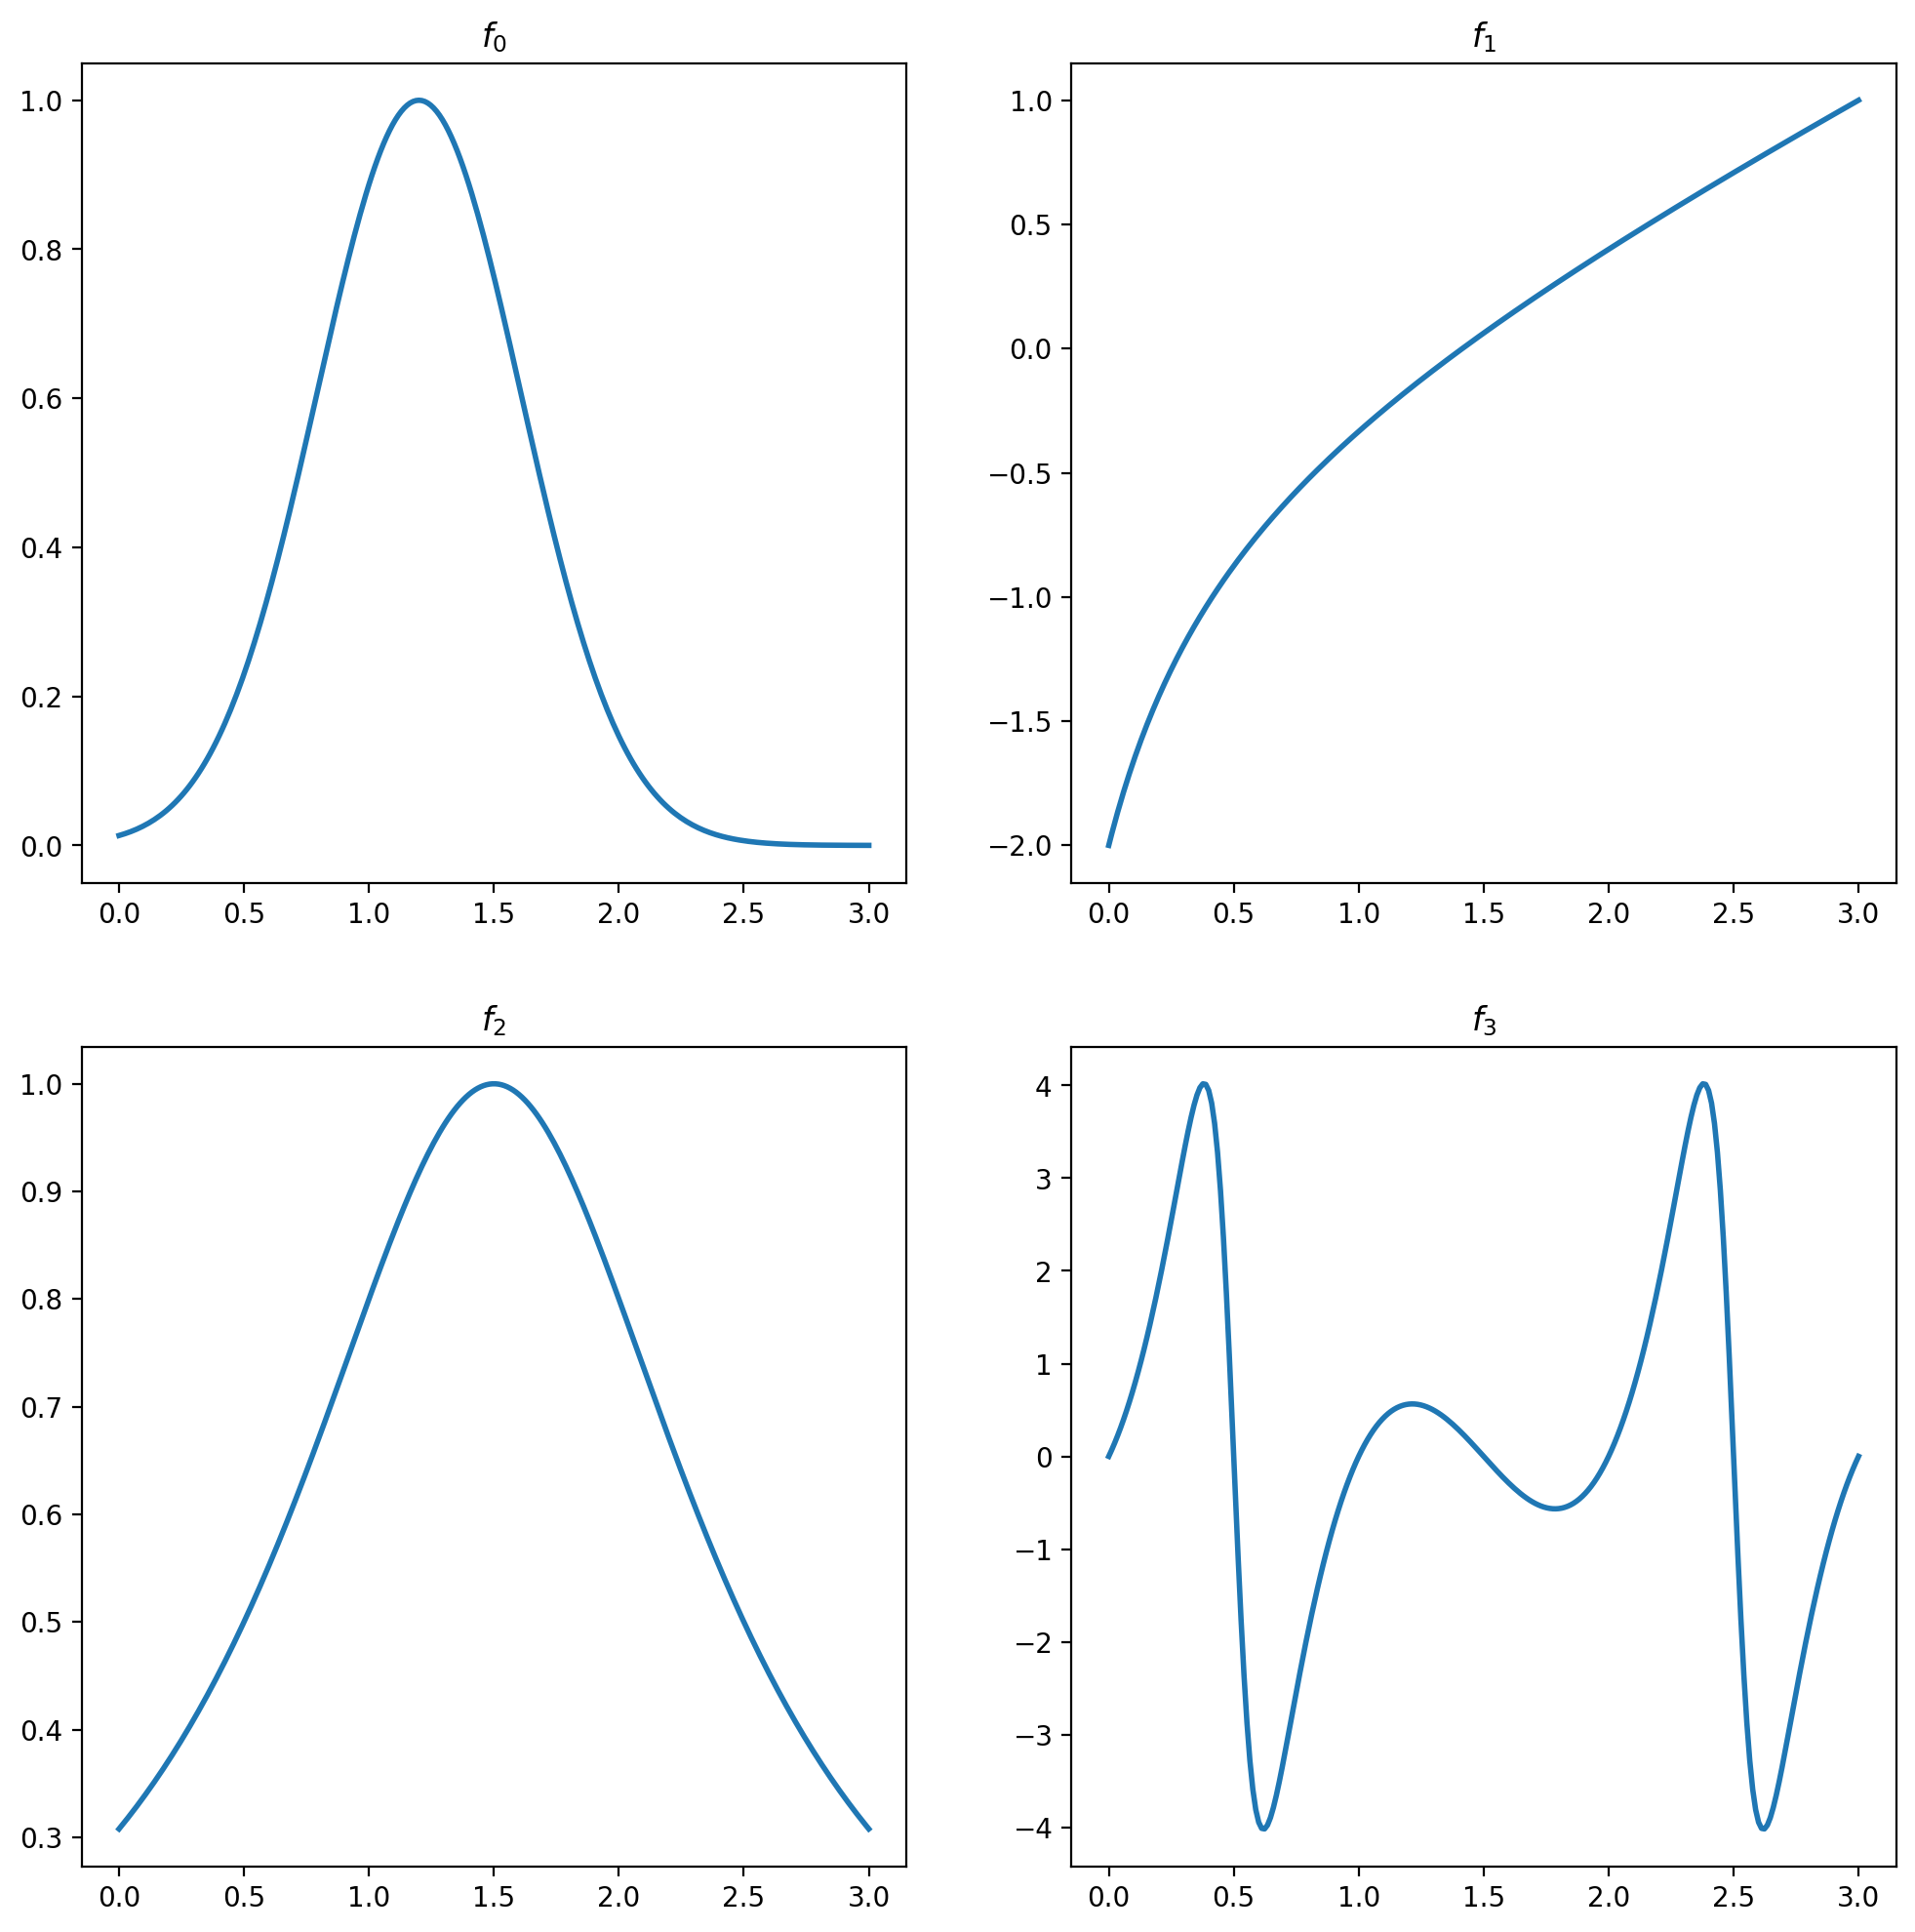

In [34]:
# Graphique des fonctions

a, b = 0, 3

xx = np.linspace(a, b, 256)
fig = plt.figure(figsize=(12, 12))
for k, fk in enumerate(f):
    ax = fig.add_subplot(2, 2, k+1)
    ax.plot(xx, fk(xx), linewidth=2)
    ax.grid(False)
    ax.set_title(f'$f_{k:}$')

### Question 4.2

> * Ajoutez sur les figures précédentes les polynômes interpolateurs qui passent par $N$ points équi-répartis des graphes des fonctionss avec $N\in\lbrace 4, 8, 12, 16, 20\rbrace$.
> * Que remarquez-vous lorsque $N$ augmente ?


<div style="color:#0008ff;font-family:courier; font-size:100%; font-weight:bold;background-color:powderblue;">

Encore une fois la solution ci-dessus est peut-être trop compacte et probablemenent pas reproductible par vous.
    
Aussi privillégiez une approche plus simple, fondée sur les enseignements de la fiche de TP01: voir le tutoriel en fin.
</div>

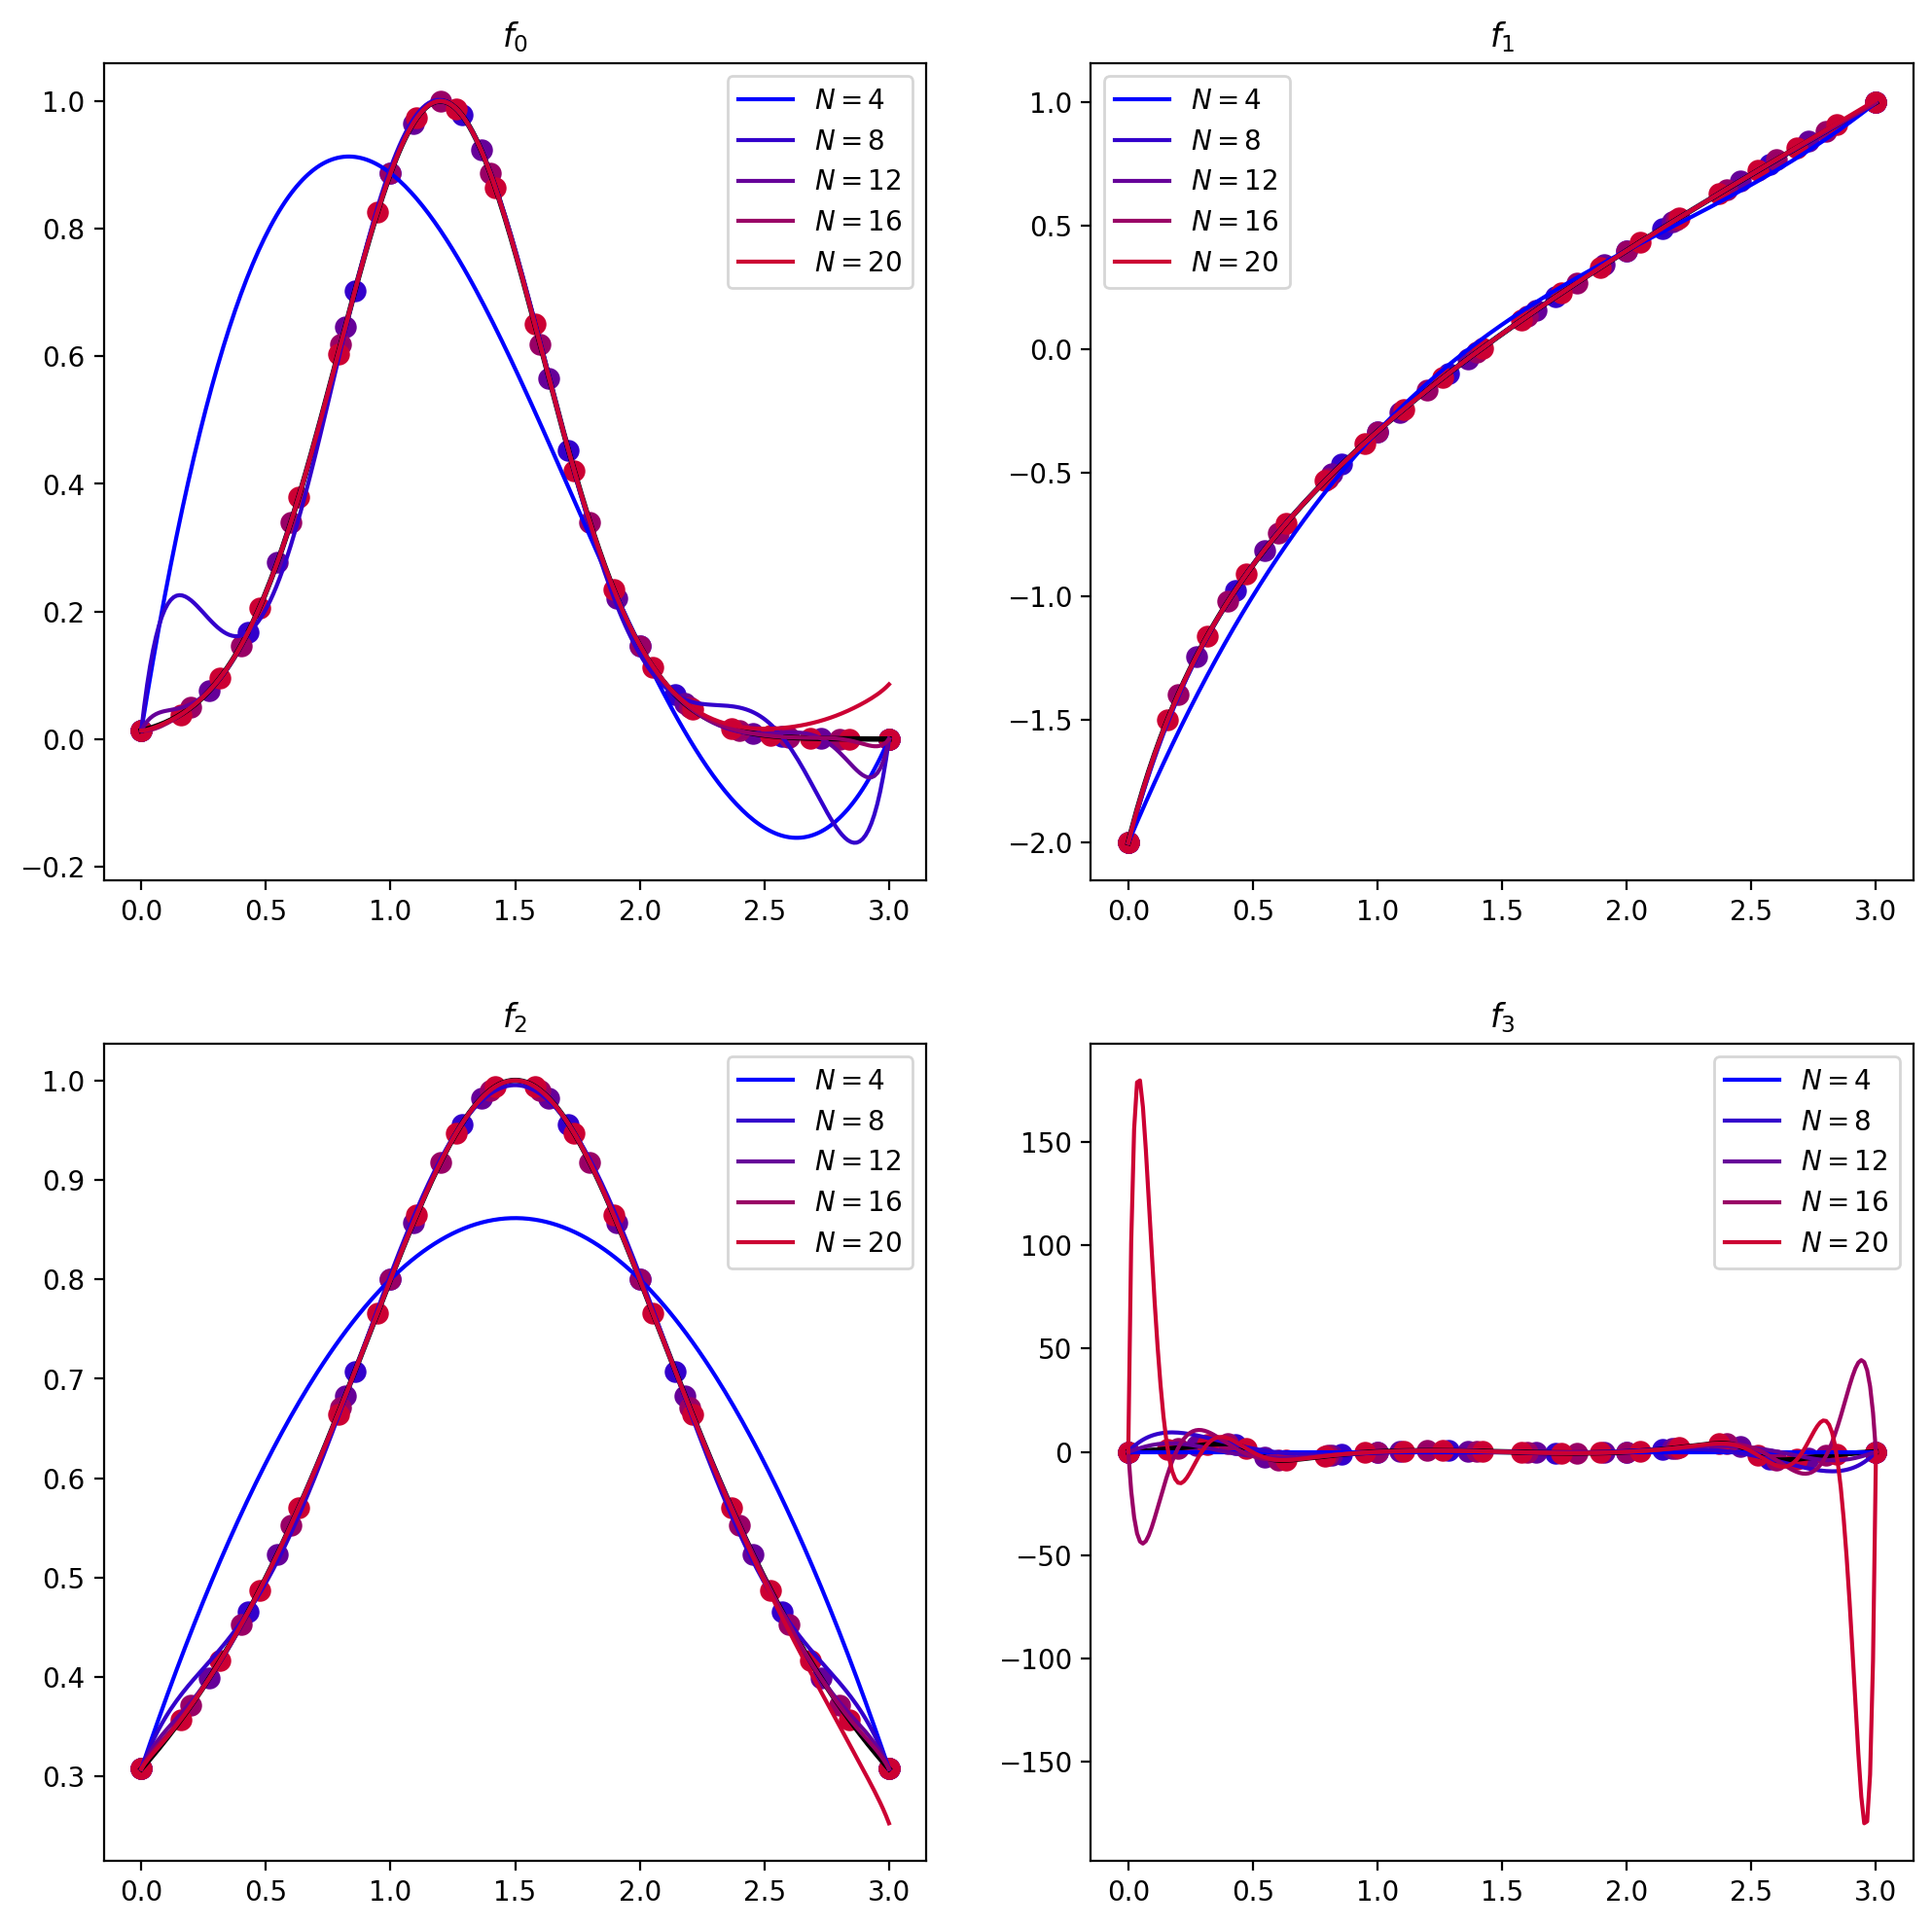

In [35]:
# METTRE LE CODE ICI

a, b = 0, 3

liste_N = [4*k for k in range(1, 6)]
liste_c = [(k/len(liste_N), 0, 1-k/len(liste_N)) for k in range(len(liste_N))]
xx = np.linspace(a, b, 256)
fig = plt.figure(figsize=(12, 12))
for k, fk in enumerate(f):
    ax = fig.add_subplot(2, 2, k+1)
    ax.plot(xx, fk(xx), linewidth=2, color='black')
    for i, N in enumerate(liste_N):
        x = np.linspace(a, b, N)
        ax.scatter(x, fk(x), color=liste_c[i], s=50)
        ax.plot(xx, interp(x, fk(x), xx), color=liste_c[i], label=f"$N={N}$")
    ax.grid(False)
    ax.set_title(f"$f_{k}$")
    ax.legend()


<div style="color:#0008ff;font-family:courier; font-size:100%; font-weight:bold;background-color:powderblue;">

Commentaires :
<ul>
<li> Dans cadre des fonction $f_0, f_1,f_2$, lorsque N augmente le polynôme d'interpolation se rapproche de plus en plus de la fonction. Le polynôme d'interpolation semble donc converger vers la fonction lorsque le degré d'interpolation augmente. 
<li> Ce comportement n'est manheureusement pas observé dans le cadre de la fonction $f_3$ !!! Ceci pointe un phénomène observé dans le comportement asymptotique (c'est-à-dire lorsque $N$ devient trop grand) de l'interpolation de Lagrange sur lequel nous reviendrons. 
    </ul>    
</div>

<div style="color:#ff0008;font-family:courier; font-size:100%; font-weight:bold;background-color:powderblue;">

En guise d'exploration  : 
    
à ce stade, grace à une <span style="background-color: #FFFFFF; color:#000000">bibliothèque de Python</span>, 
<ul>
<li> vous êtes capables  d'évaluer un polynôme donc les coefficients sont donnés. 
    <span style="background-color: #FFFFFF; color:#000000">Savez-vous quel algorithme est utilisé par Python pour cette évaluation ?</span>
<li> vous êtes capables  de construire le polynôme d'interpolation de Lagrange passant par un nuage de points. 
    <span style="background-color: #FFFFFF; color:#000000">Sauriez-vous extraire les coefficients de ce polynôme et les afficher selon l'ordre croissant et décroissant des monômes ?</span>
    
</ul>    
</div>

<div style="color:#ff08ff;font-family:courier; font-size:100%; font-weight:bold;background-color:powderblue;">

Un petit tutoriel :   

Je propose ici une pour ceux qui peuvent le comprendre un petit tutoriel sur une technique de mise en oeuvre 
informatique de la résolution de problèmes (qui est un pendant en Mathématiques de la <span style="background-color: #FFFFFF; color:#000000">factorisation</span>) appelé en géni-logiciel <span style="background-color: #FFFFFF; color:#000000">abstraction des variations</span>.
    
Je l'applique directement pour réponse à la question  <span style="background-color: #FFFFFF; color:#000000">Question 4.2</span>. 
</div>


<div style="color:#0008ff;font-family:courier; font-size:100%; font-weight:bold;background-color:powderblue;">

On peut répondre à la **Question 4.2**  en privillégiant une approche fondée sur les enseignements de la fiche de TP01: 
On identifie ce qui varient et on le factorise. 

Il y'a ici des choses qui varient:
<ul>
    <li> la fonction à tracer <span style="background-color: #FFFFFF; color:#000000">f</span>
<li> le nombre de points équidistants <span style="background-color: #FFFFFF; color:#000000">N</span>
</ul>

On peut donc définir une fonction qui va réaliser ce qui est demandé pour chacun des jeux de données ici <span style="background-color: #FFFFFF; color:#000000">f</span> et <span style="background-color: #FFFFFF; color:#000000">N</span>.
On peut appeler cette fonction <span style="background-color: #FFFFFF; color:#000000">simulation(f, N)</span>  ou mieux encore <span style="background-color: #FFFFFF; color:#000000">simulation(f, N, c, xx)</span>  où c est la couleur qu'on voudrait la même pour les points 
d'interpolation et le polynôme d'interpolation. On utilise ici les mêmes points pour le graphique <span style="background-color: #FFFFFF; color:#000000">xx</span> dans tous les cas,
aussi on peut le passer en paramètre, ce qui nous permettra de le faire varier si on le désire.
    
Mais comme il est possible qu'on nous demande de supperposer sur le même graphique un jeu de variation de l'un des paramètres, on va passer en argument la fenêtre graphique sur laquelle on dessine. C'est ici que l'on a besoin 
d'une instance transportable de l'objet graphique (désignée par <span style="background-color: #FFFFFF; color:#000000">ax</span>) et non de l'instance globale référencée 
    par <span style="background-color: #FFFFFF; color:#000000">plt</span>.

Notre fonction devient donc <span style="background-color: #FFFFFF; color:#000000">simulation(f, N, c, xx, ax)</span>. 
Et avec cela sous la main on peut procéder comme ci-dessous.


</div>

In [37]:
# la fonction à définir 
a, b = 0, 3
def simulation(f, N, c, xx, ax):
    x = np.linspace(a, b, N)
    ax.plot(xx, f(xx), color='black')
    ax.scatter(x, f(x), color=c)
    ax.plot(xx, interp(x, f(x), xx), color = c,  label=f"$N={N}$")    
    ax.set_title(f.__name__)

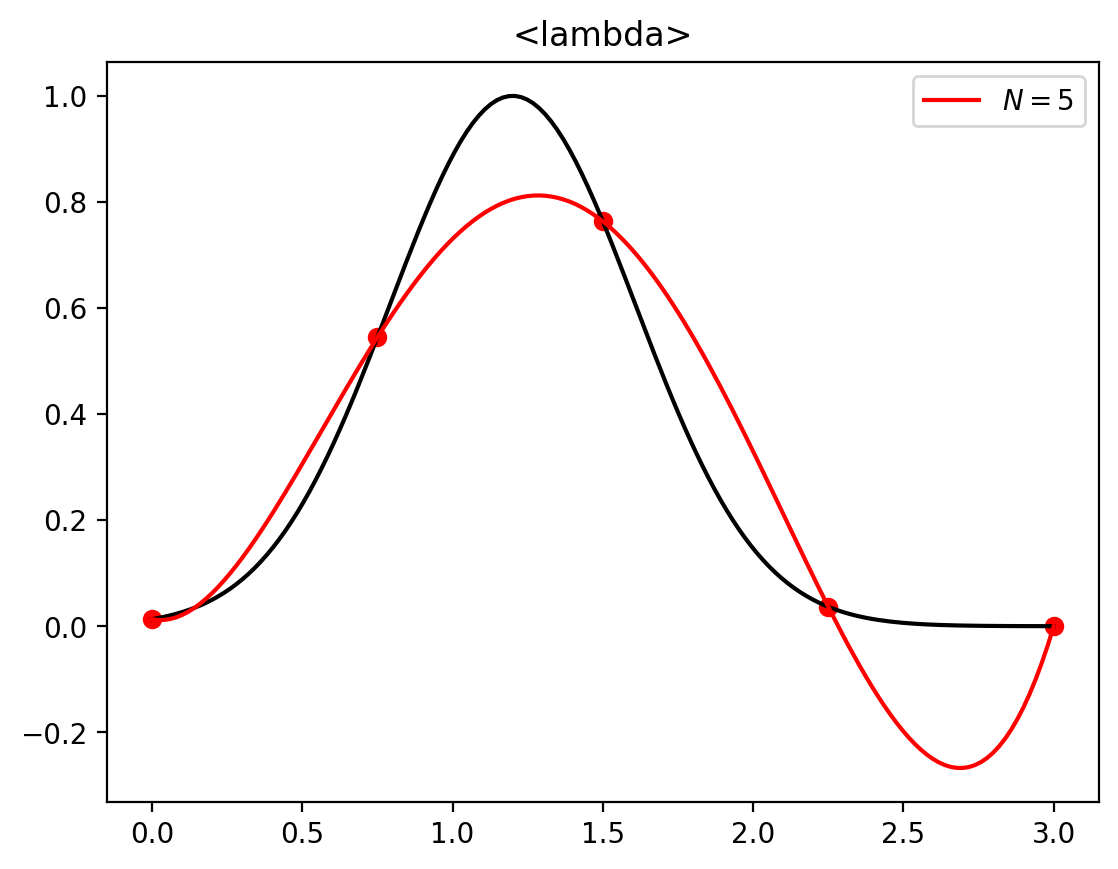

In [38]:
# on teste la fonction
xx = np.linspace(a,b, 150)
fig, ax = plt.subplots(1,1)
simulation(f[0],5, 'red', xx, ax)
ax.legend()
plt.show()

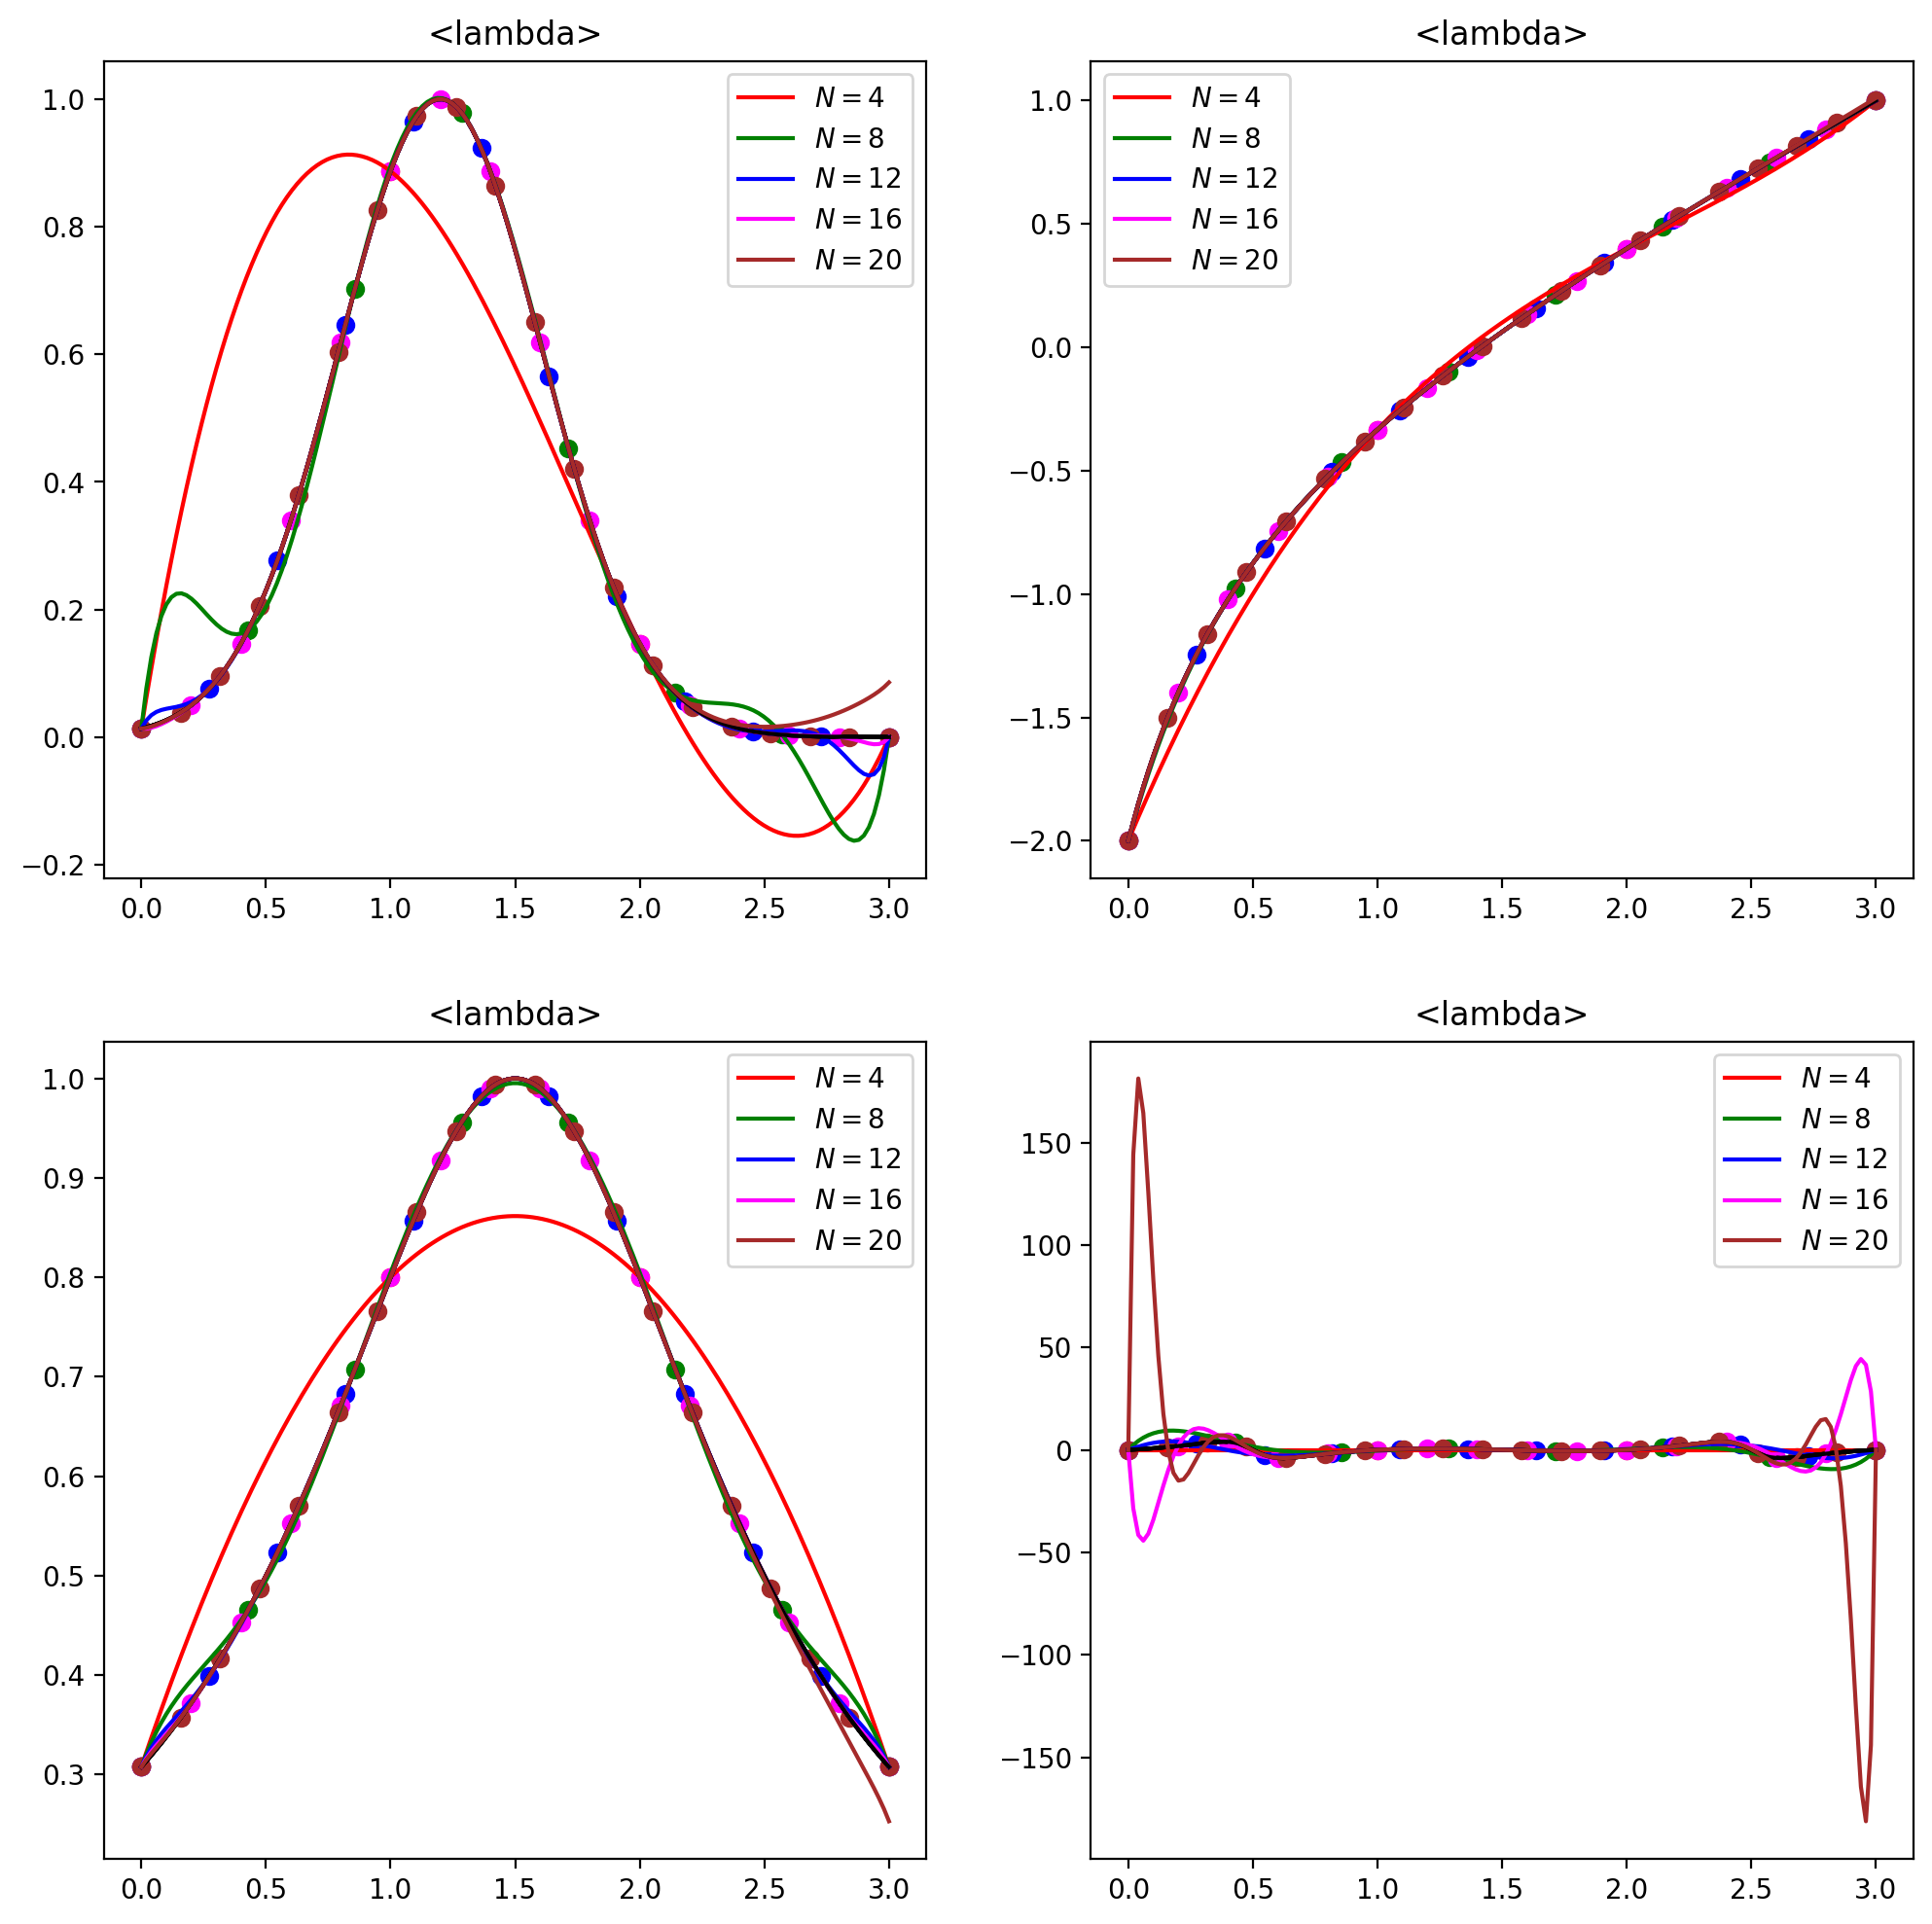

In [39]:
# ON PEUT A PRESENT REPONDRE A  LA QUESTION

# création des objets graphiques 
fig, ax = plt.subplots(2,2, figsize =(12,12))

# points pour dessiner les courbes les mêmes pour tous
xx = np.linspace(a,b, 150)

# on dispose deja de la liste de fonctions : f
# on définit la liste des N  :
liste_N = [4, 8, 12, 16, 20]
# on définit la liste des couleurs : il suffit de choisir 5 couleurs
liste_c = ['red', 'green', 'blue', 'magenta', 'brown']

# on travaille dans le premier cadrant ax[0,0], avec la fonction f[0] et on répète avec les autres
for i in range(len(liste_N)):
    simulation(f[0], liste_N[i], liste_c[i], xx, ax[0,0])
ax[0,0].legend()

# on travaille dans le second cadrant ax[0,1], avec la fonction f[1]
for i in range(len(liste_N)):
    simulation(f[1], liste_N[i], liste_c[i], xx, ax[0,1])
ax[0,1].legend()

# on travaille dans le troisième cadrant ax[1,0], avec la fonction f[2]
for i in range(len(liste_N)):
    simulation(f[2], liste_N[i], liste_c[i], xx, ax[1,0])
ax[1,0].legend()

# on travaille dans le quatrième cadrant ax[1,1], avec la fonction f[3]
for i in range(len(liste_N)):
    simulation(f[3], liste_N[i], liste_c[i], xx, ax[1,1])
ax[1,1].legend()

plt.show()

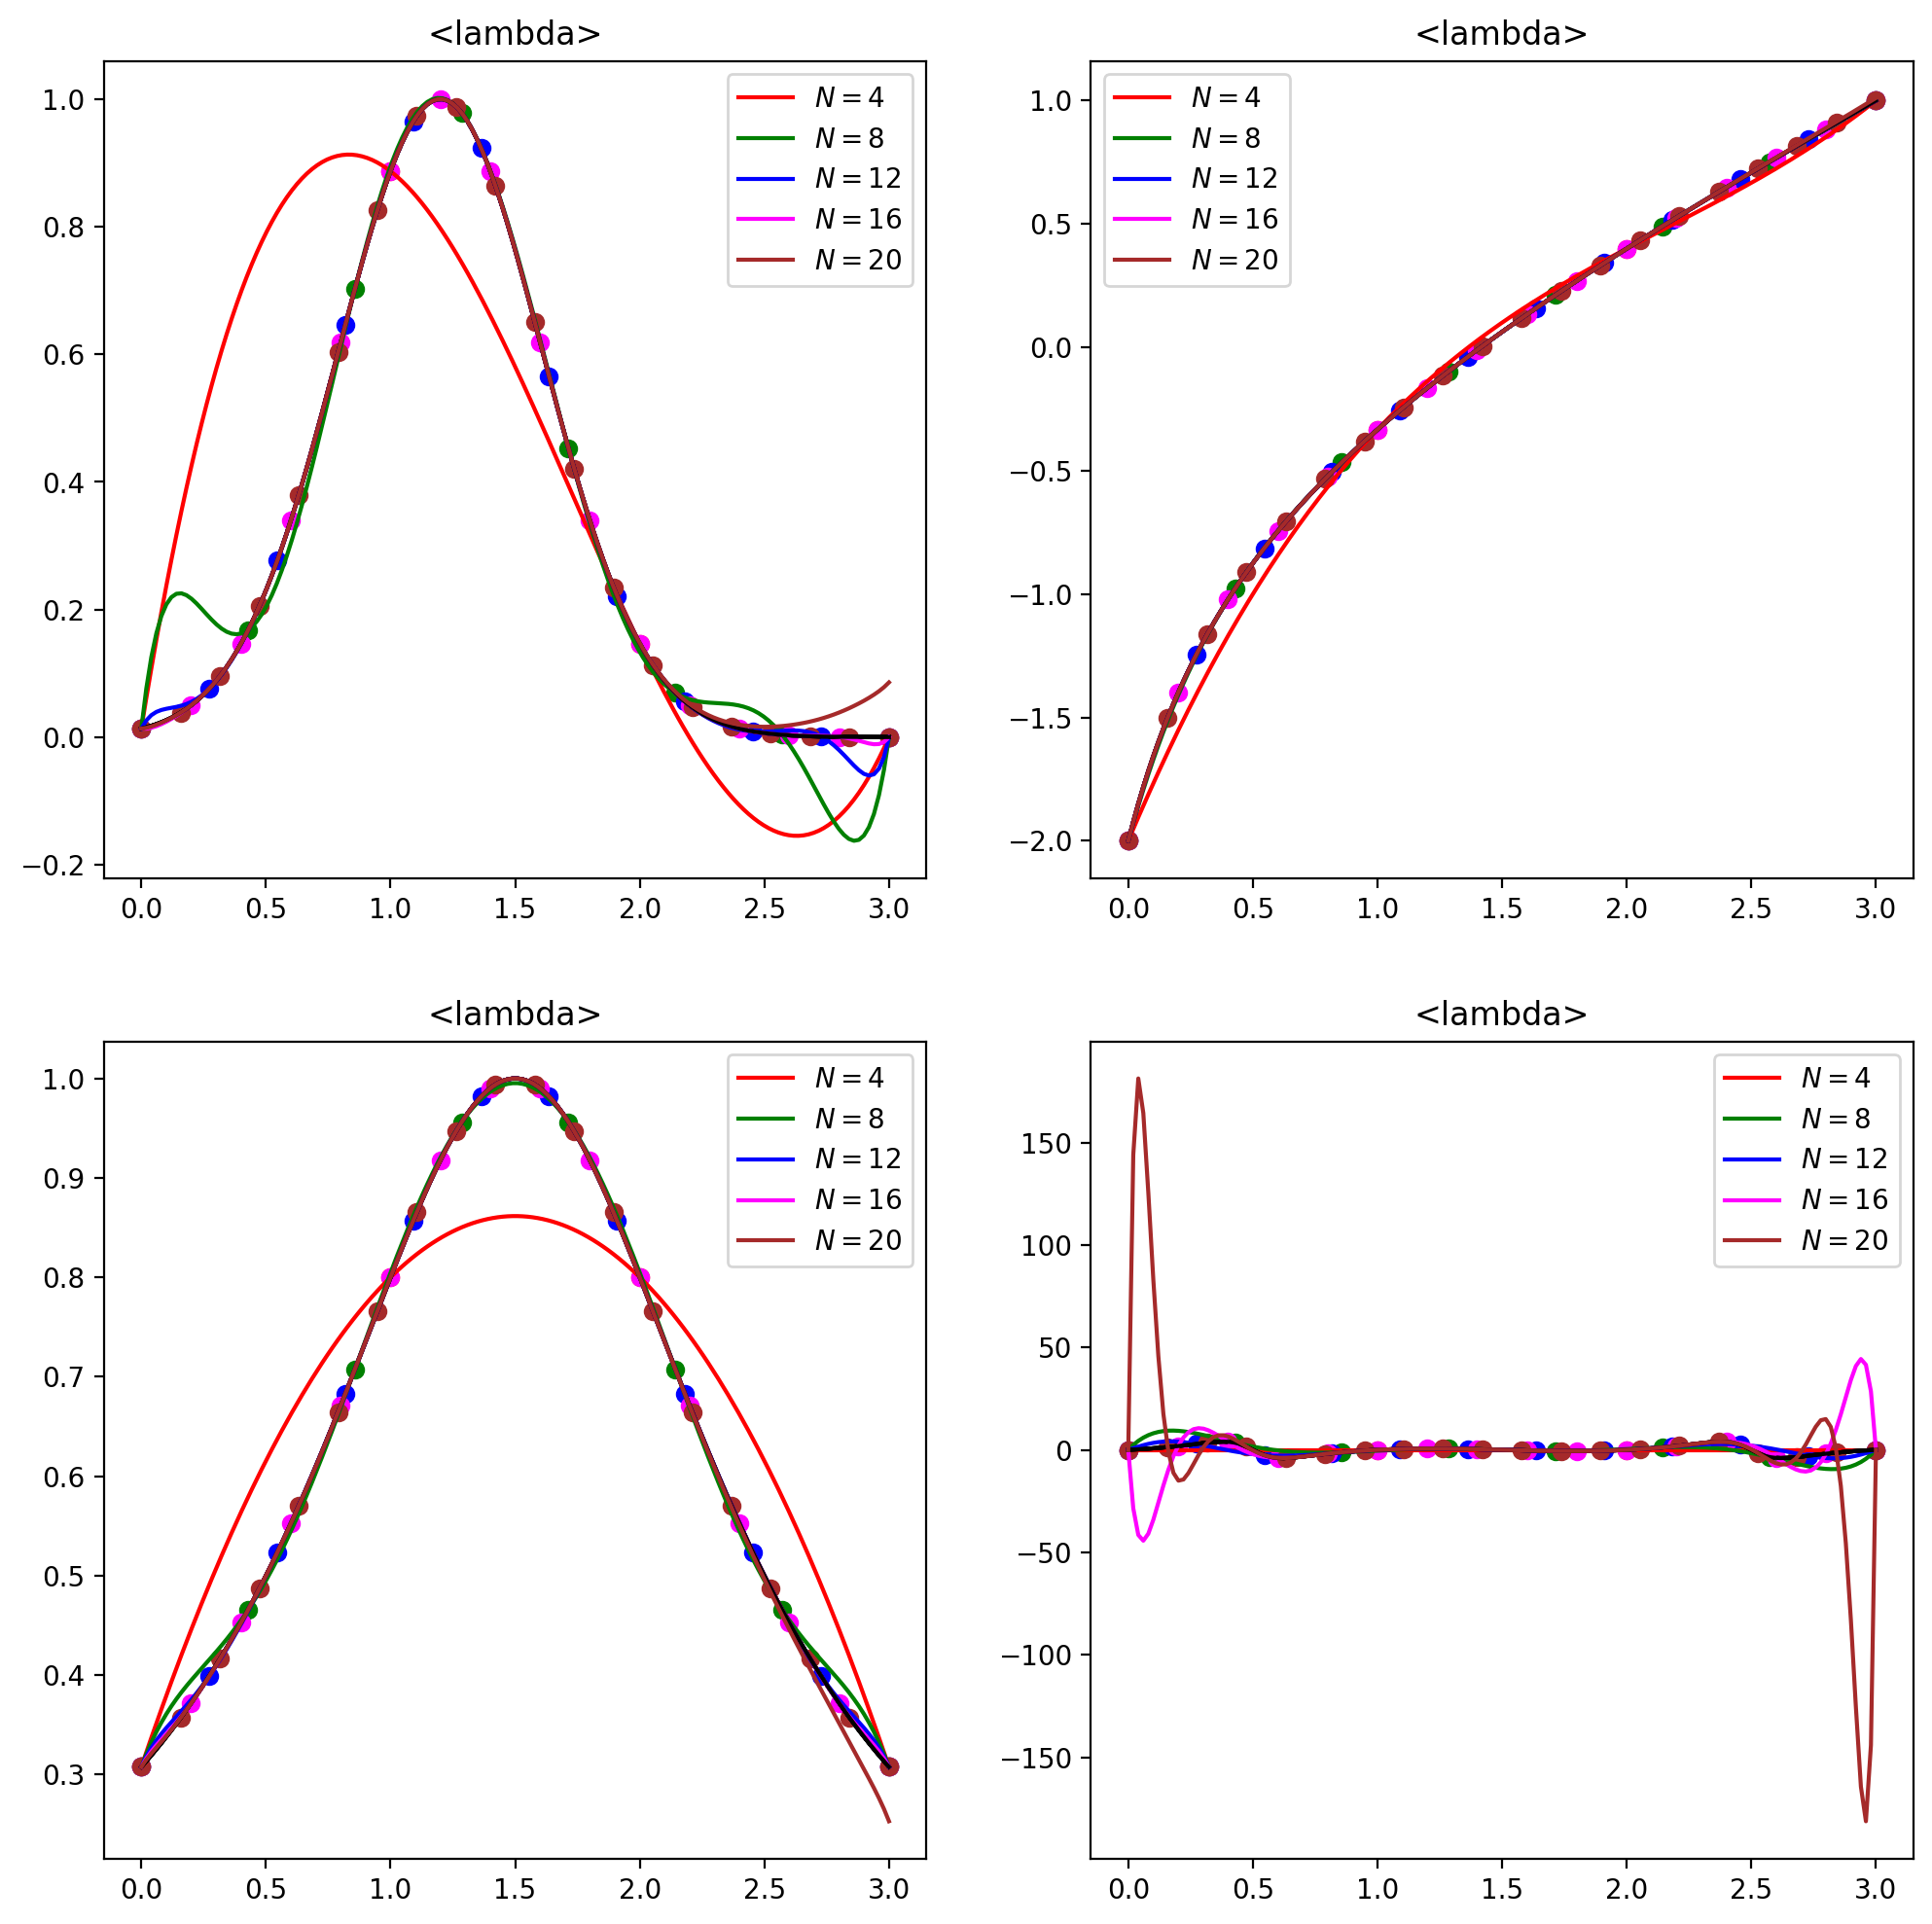

In [40]:
# On peut éviter ces codes redondants ( on répète le même code pour chaque fonction de la liste des fonctions)
# Pour cela il suffit de trouver moyen de convertir le tableau à deux entrées ax[i,j] en un tableau à une entrée ax[k]

fig, ax = plt.subplots(2,2, figsize =(12,12))
# points pour le graphique
xx = np.linspace(a,b, 150)
# on a deja la liste de fonctions : f
# la liste des N  est :
liste_N = [4, 8, 12, 16, 20]
#liste des couleurs : il suffit de choisir 5 couleurs
liste_c = ['red', 'green', 'blue', 'magenta', 'brown']
#liste_c = ['#2200EE', '#4400CC', '#AA00AA', '#CC0044', '#FF0022'] # un autre choix de couleurs (plus graduées)

ax = ax.reshape((4,))                               # c'est ici que la conversion a lieu 
for k in range(ax.size):
    for i in range(len(liste_N)):
        simulation(f[k], liste_N[i], liste_c[i], xx, ax[k])
    ax[k].legend()
plt.show()